<a href="https://colab.research.google.com/github/preshitgupta618-cell/Exploratory-Data-Analysis-Assignment/blob/main/Exploratory%20Data%20Analysis%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/House Price India.csv')


print(df.info())
print(df.describe())


print("Missing values per column:\n", df.isnull().sum())

df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

In [5]:
#Q1 :- Find the average, median, and standard deviation of house prices.

avg_price = df['Price'].mean()
median_price = df['Price'].median()
std_price = df['Price'].std()

print(f"Average: {avg_price}\nMedian: {median_price}\nStd Dev: {std_price}")

Average: 538932.2183310534
Median: 450000.0
Std Dev: 367532.3808039669


In [6]:
#Q2 :- Most Common Number of Bedrooms.

common_bedrooms = df['number of bedrooms'].mode()[0]
print(f"Most common number of bedrooms: {common_bedrooms}")

Most common number of bedrooms: 3


Skewness: 4.269297720707116


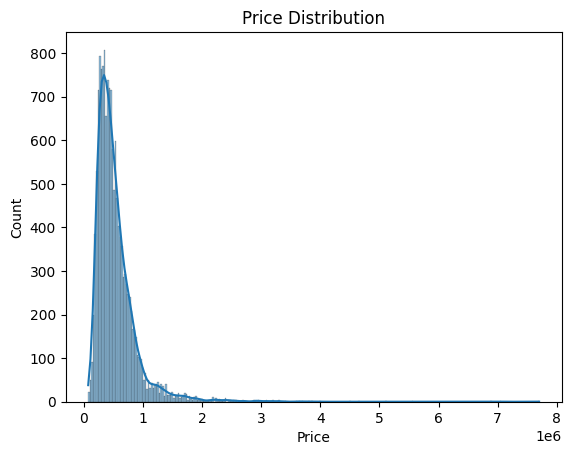

In [7]:
#Q3 :- Check if the price data is skewed.

skewness = df['Price'].skew()
print(f"Skewness: {skewness}")

sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

In [8]:
#Q4 :- Find the average price for each bedroom count.

avg_price_bed = df.groupby('number of bedrooms')['Price'].mean()
print(avg_price_bed)

number of bedrooms
1     3.089638e+05
2     3.985476e+05
3     4.632776e+05
4     6.361988e+05
5     7.752550e+05
6     8.375815e+05
7     1.016544e+06
8     1.208455e+06
9     7.766663e+05
10    8.200000e+05
11    5.200000e+05
33    6.400000e+05
Name: Price, dtype: float64


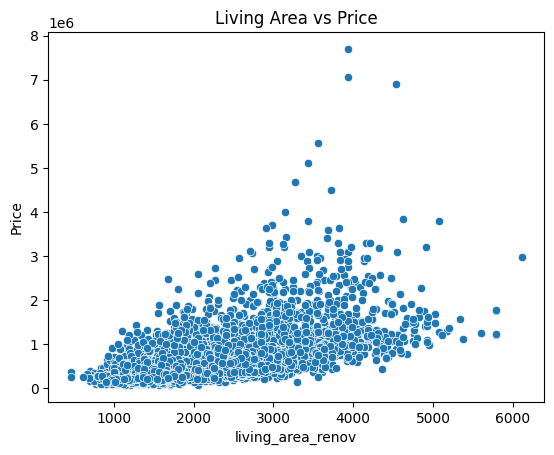

In [14]:
#Q5 :- Analyze price vs. area without basement.

sns.scatterplot(x=df['living_area_renov'], y=df['Price'])
plt.title("Living Area vs Price")
plt.show()

In [15]:
#Q6 :- Identify houses with high prices but small areas.

# Houses in top 10% price but bottom 10% area
anomalies = df[(df['Price'] > df['Price'].quantile(0.9)) &
               (df['living_area_renov'] < df['living_area_renov'].quantile(0.1))]
print(anomalies)

               id   Date  number of bedrooms  number of bathrooms  \
2059   6762810797  42525                   6                 4.50   
3122   6762811752  42540                   3                 3.25   
6249   6762812106  42585                   4                 2.75   
6688   6762812187  42592                   2                 2.00   
7741   6762811355  42607                   4                 3.00   
7960   6762811220  42609                   3                 2.50   
10260  6762811018  42650                   5                 3.50   
10921  6762812023  42662                   3                 3.00   
10922  6762812074  42662                   4                 2.00   
11413  6762811257  42670                   4                 2.50   
12689  6762811470  42692                   4                 3.50   

       living area  lot area  number of floors  waterfront present  \
2059          3902      3880               3.0                   0   
3122          3050     18892   

In [16]:
#Q7 :- Compare prices based on floors and waterfront status.

pivot_table = df.pivot_table(index='number of floors', columns='waterfront present', values='Price', aggfunc='mean')
print(pivot_table)

waterfront present             0             1
number of floors                              
1.0                 4.323724e+05  1.211081e+06
1.5                 5.476162e+05  1.232507e+06
2.0                 6.357742e+05  2.075931e+06
2.5                 1.087654e+06  3.280000e+06
3.0                 5.558095e+05  1.655000e+06
3.5                 1.205875e+06           NaN


In [17]:
#8 :- Identify the range of prices.

min_p = df['Price'].min()
max_p = df['Price'].max()
print(f"Min: {min_p}, Max: {max_p}")

Min: 78000, Max: 7700000


In [19]:
#Q9 :- Which zipcode/area has the highest average price?

top_location = df.groupby('Postal Code')['Price'].mean().sort_values(ascending=False).head(1)
print(f"Highest Price Location: {top_location}")

Highest Price Location: Postal Code
122071    2.348311e+06
Name: Price, dtype: float64


In [ ]:
#Based on the analysis above, here are 5 key business insights:


#1.Price Distribution: The house prices are likely right-skewed, indicating the majority of the market is concentrated in the mid-to-lower price range with a few high-end luxury outliers.


#2.Bedroom Demand: The most common bedroom count (from Q2) indicates the primary target demographic (e.g., 3-bedroom houses for families).


#3.Waterfront Premium: Houses with waterfront views command a significantly higher price, suggesting that "location/view" is a stronger price driver than just "size".


#4.Area Correlation: There is a strong linear relationship between living area and price, but anomalies (Q6) suggest that location and renovation status can override size.


#5.Geographic Variation: Average prices vary significantly by Zipcode/Postcode, highlighting that real estate value is heavily dependent on specific regional demand.